In [296]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.quantum_info import Statevector

from itertools import product

In [297]:
import numpy as np

def bragg_hamiltonian(delta: float, omega: float) -> np.ndarray:
    return np.array(
        [
            [4 + delta, omega, 0],
            [omega, 0, omega],
            [0, omega, 4 - delta],
        ],
        dtype=float,
    )

In [298]:
H = bragg_hamiltonian(delta=0, omega=0.5)
print(np.allclose(H, H.conj().T))

True


In [299]:
eigenvalues, eigenvectors = np.linalg.eigh(H)
ground_energy = eigenvalues[0]
ground_state = eigenvectors[:, 0]

populations = np.abs(ground_state) ** 2
p_minus = populations[0]
p_zero = populations[1]
p_plus = populations[2]

print(f"Exact Ground Energy: ", ground_energy)
print(f"Exact Ground State: ", ground_state)

Exact Ground Energy:  -0.12132034355964301
Exact Ground State:  [-0.11957316  0.98559856 -0.11957316]


In [300]:
delta_values = np.linspace(-8, 8, 300)
omega_values = [0.1, 0.5, 1.0]

all_energies = []

for omega in omega_values:
    energies_for_this_omega = []
    for delta in delta_values:
        H = bragg_hamiltonian(delta, omega=omega)
        eigenvalues = np.linalg.eigvalsh(H)
        energies_for_this_omega.append(eigenvalues)
    all_energies.append(np.array(energies_for_this_omega))

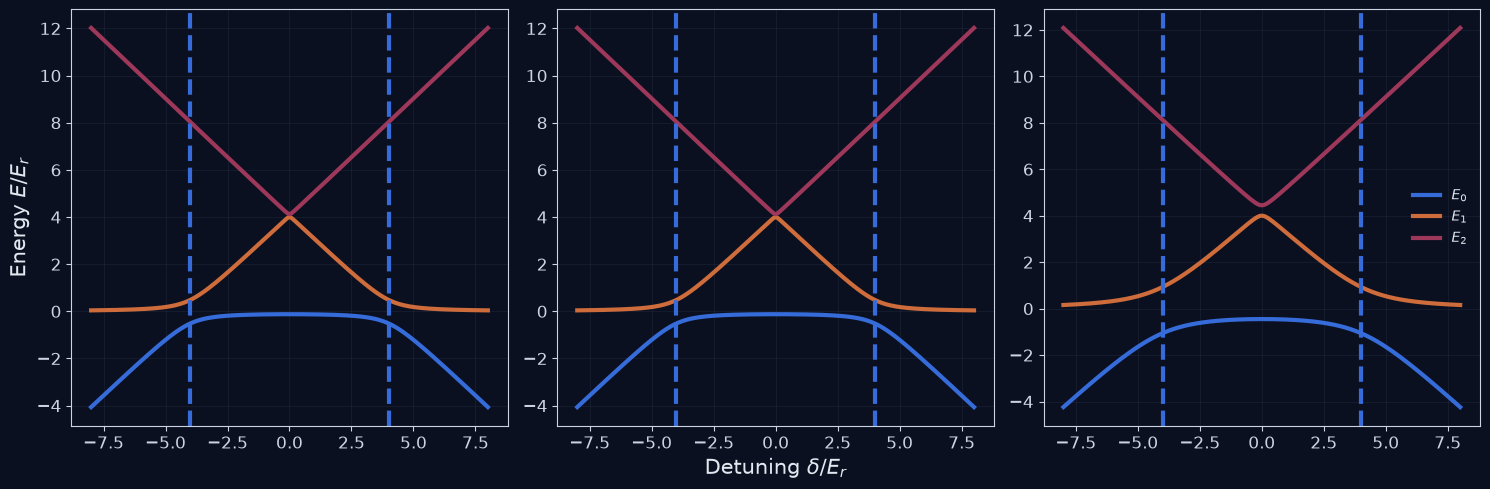

In [301]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for level in range(3):
    axes[0].plot(delta_values, all_energies[1][:, level], label=f"$E_{level}$")
    axes[1].plot(delta_values, all_energies[1][:, level], label=f"$E_{level}$")
    axes[2].plot(delta_values, all_energies[2][:, level], label=f"$E_{level}$")

for axis_idx in range(3):
    axes[axis_idx].axvline(-4, linestyle="--")
    axes[axis_idx].axvline(4, linestyle="--")

axes[1].set_xlabel(r"Detuning $\delta/E_r$")
axes[0].set_ylabel(r"Energy $E/E_r$")
plt.legend()
plt.tight_layout()
plt.show()

In [302]:
population_data = []

for delta in delta_values:
    H = bragg_hamiltonian(delta, omega=0.5)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    ground_state = eigenvectors[:, 0]
    population_data.append(np.abs(ground_state) ** 2)

population_data = np.array(population_data)

In [303]:
population_data = []

for delta in delta_values:
    H = bragg_hamiltonian(delta, omega=0.5)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    ground_state = eigenvectors[:, 0]
    population_data.append(np.abs(ground_state) ** 2)

population_data = np.array(population_data)

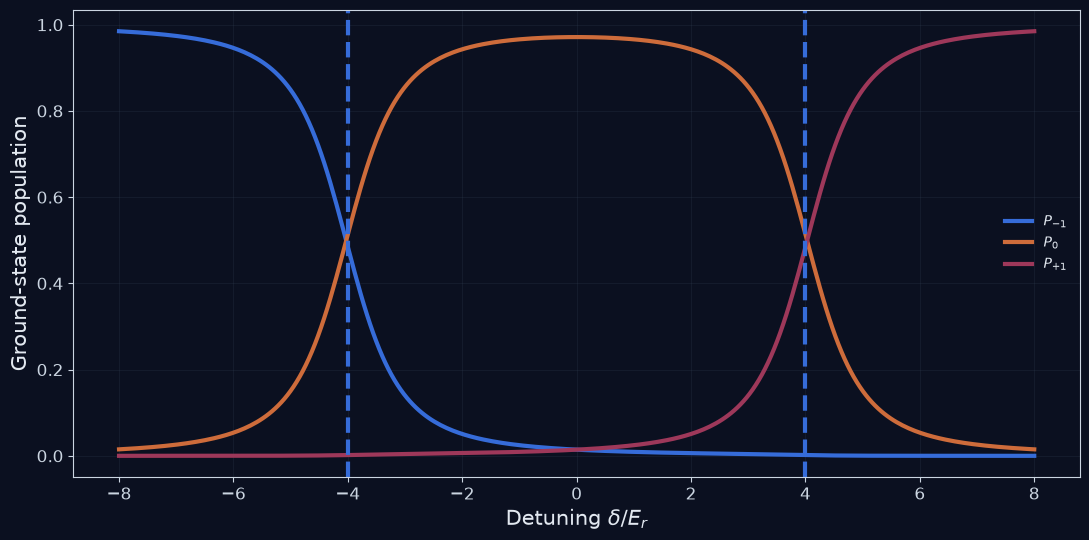

In [304]:
plt.plot(delta_values, population_data[:, 0], label=r"$P_{-1}$")
plt.plot(delta_values, population_data[:, 1], label=r"$P_0$")
plt.plot(delta_values, population_data[:, 2], label=r"$P_{+1}$")

plt.axvline(-4, linestyle="--")
plt.axvline(4, linestyle="--")
plt.xlabel(r"Detuning $\delta/E_r$")
plt.ylabel("Ground-state population")
plt.legend()
plt.tight_layout()
plt.show()

In [305]:
omega_values = [0.05, 0.1, 0.2, 0.5]

centre = 4.0
width = 1.0
points = 2001
deltas = np.linspace(centre - width, centre + width, points)
gaps = []
indexes = []

for omega in omega_values:
    gaps_for_this_omega = []
    for delta in deltas:
        energies = np.linalg.eigvalsh(bragg_hamiltonian(delta, omega))
        gaps_for_this_omega.append(energies[1] - energies[0])
    gaps.append(np.array(gaps_for_this_omega))

for i in range(4):
    gaps[i] = np.array(gaps[i])

min_gaps = []
for i in range(len(omega_values)):
    min_gaps.append(np.min(gaps[i]))

# Print table
print("\n" + "="*75)
print(f"{'Ω':^12} {'ΔE_min':^18} {'2Ω':^15} {'|ΔE_min - 2Ω|/(2Ω)':^25}")
print("="*75)

for i, omega in enumerate(omega_values):
    two_omega = 2 * omega
    relative_error = abs(min_gaps[i] - two_omega) / two_omega
    print(f"{omega:^12.4f} {min_gaps[i]:^18.8f} {two_omega:^15.4f} {relative_error:^25.8f}")

print("="*75)


     Ω             ΔE_min             2Ω           |ΔE_min - 2Ω|/(2Ω)    
   0.0500        0.09999854         0.1000             0.00001465        
   0.1000        0.19998454         0.2000             0.00007731        
   0.2000        0.39987529         0.4000             0.00031177        
   0.5000        0.99807493         1.0000             0.00192507        


In [306]:
def padded_bragg_hamiltonian(
    delta: float,
    omega: float,
    penalty: float = 13.0,
) -> np.ndarray:
    return np.array(
        [
            [4 + delta, omega, 0, 0],
            [omega, 0, omega, 0],
            [0, omega, 4 - delta, 0],
            [0, 0, 0, penalty],
        ],
        dtype=float,
    )

H3 = bragg_hamiltonian(delta=1.0, omega=0.5)
H4 = padded_bragg_hamiltonian(delta=1.0, omega=0.5)

e3 = np.linalg.eigvalsh(H3)
e4 = np.linalg.eigvalsh(H4)

print(e3)
print(e4[:3])

[-0.12865236  3.07793022  5.05072214]
[-0.12865236  3.07793022  5.05072214]


In [307]:
from itertools import product
from qiskit.quantum_info import Pauli, SparsePauliOp

def pauli_decompose(matrix: np.ndarray, tolerance: float = 1e-12):
    labels = []
    coefficients = []

    for symbols in product("IXYZ", repeat=2):
        label = "".join(symbols)
        pauli_matrix = Pauli(label).to_matrix()
        coefficient = np.trace(pauli_matrix @ matrix) / 4

        if abs(coefficient) > tolerance:
            labels.append(label)
            coefficients.append(np.real_if_close(coefficient))

    return SparsePauliOp(labels, coefficients)

In [308]:
H_matrix = padded_bragg_hamiltonian(
    delta=4.0,
    omega=0.5,
    penalty=13.0,
)

H_pauli = pauli_decompose(H_matrix)

print(np.allclose(H_pauli.to_matrix(), H_matrix))

True


In [309]:
def make_ansatz():
    theta = ParameterVector("theta", 4)

    circuit = QuantumCircuit(2)
    circuit.ry(theta[0], 0)
    circuit.ry(theta[1], 1)
    circuit.cx(0, 1)
    circuit.ry(theta[2], 0)
    circuit.ry(theta[3], 1)

    return circuit

In [310]:
estimator = StatevectorEstimator()
ansatz = make_ansatz()
optimizer = COBYLA(maxiter=500)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
)

vqe_result = vqe.compute_minimum_eigenvalue(H_pauli)
vqe_energy = vqe_result.eigenvalue

eigenvalues = np.linalg.eigvalsh(H_matrix)
exact_energy = np.min(eigenvalues)

eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
exact_state_3d = eigenvectors[:, 0]

energy_error = abs(vqe_energy - exact_energy)
print(energy_error)

7.64369196826209e-08


In [311]:
optimal_parameters = vqe_result.optimal_parameters
optimal_circuit = ansatz.assign_parameters(optimal_parameters)
vqe_state = Statevector.from_instruction(optimal_circuit).data

exact_state_4d = np.array(
    [
        exact_state_3d[0],
        exact_state_3d[1],
        exact_state_3d[2],
        0.0,
    ],
    dtype=complex,
)

fidelity = abs(np.vdot(exact_state_4d, vqe_state)) ** 2
vqe_populations = np.abs(vqe_state) ** 2

print(vqe_populations[0])
print(vqe_populations[1])
print(vqe_populations[2])
print(vqe_populations[3])
print(fidelity)

0.001772997927036513
0.5140131961157081
0.48421380504477285
9.124825566506032e-10
0.9999999351627985
